 # Macrophage deep dive

Results for the macrophages look interesting. 
* From DEA, it's one of the only immune cell types that show differences between the Normal EPD and RMC EPD groups. Macrophages also show a consistently high number of diffex genes across all comparisons. See 1.20-rmc-differential-expression.ipynb for more details.
* There also seems to be a change in the proportions in NL EPD samples. This is not significant but it is a low sample size. See 1.15-rmc-annotation-detailed.ipynb for more details

In this notebook, we will investigate if there is a difference in the macrophages across the sample groups.

# Environment

In [1]:
%load_ext autoreload
%autoreload 2

In [27]:
import os
os.chdir('/Users/burkelawlor/Repos/hci-xenium')

from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import spatialdata as sd
import scanpy as sc
import squidpy as sq
import anndata as ad
from spatialdata_io import xenium
import sopa

from utils.data_loading import sample_sets
from utils.proportions import *
from utils.adata_processing import *
from utils.spatial import *
from utils.diffex import DiffExAnalysis, plot_volcano

In [3]:
pd.set_option('display.width', 1000)

In [4]:
import warnings
from pandas.errors import PerformanceWarning
from anndata import ImplicitModificationWarning

warnings.filterwarnings("ignore", category=PerformanceWarning)
warnings.filterwarnings("ignore", category=ImplicitModificationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Load data

In [5]:
adata_rmc = ad.read_h5ad("./data/processed/adata/rmc_annotated_5_detailed.h5ad")

# Add sample set 2
sample_name_to_condition = {}
for condition, samples in sample_sets.items():
    for s in samples:
        sample_name_to_condition[s] = condition
adata_rmc.obs['sample_set_2'] = adata_rmc.obs['sample_name'].map(sample_name_to_condition)

In [6]:
adata_macrophage = adata_rmc[adata_rmc.obs['ct_detailed'] == 'Macrophages'].copy()

# uMAP of Macrophages only

In [7]:
sc.pp.pca(adata_macrophage)
sc.pp.neighbors(adata_macrophage)
sc.tl.umap(adata_macrophage)

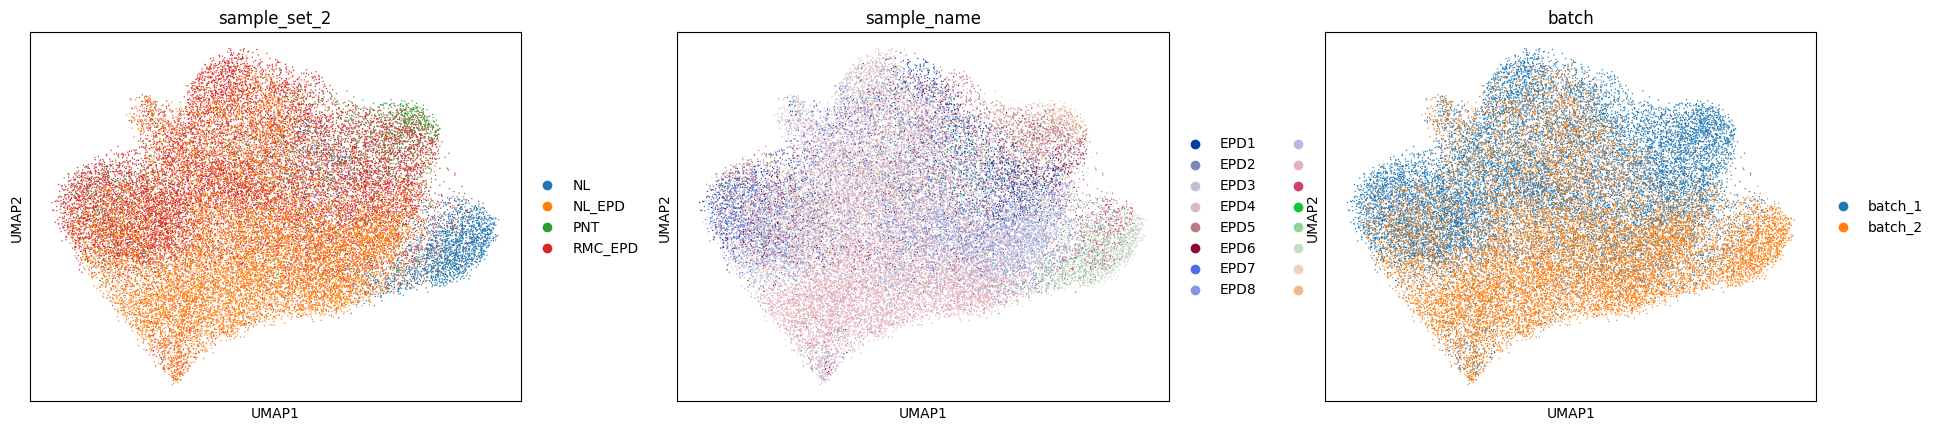

In [8]:
sc.pl.umap(adata_macrophage, color=['sample_set_2', 'sample_name', 'batch'], wspace=0.2)

Clear distinction between Normal samples vs the rest. PNT may also be distinct. NL EPD and RMC EPD mix in with one another but there's a some areas that are more of one vs the other

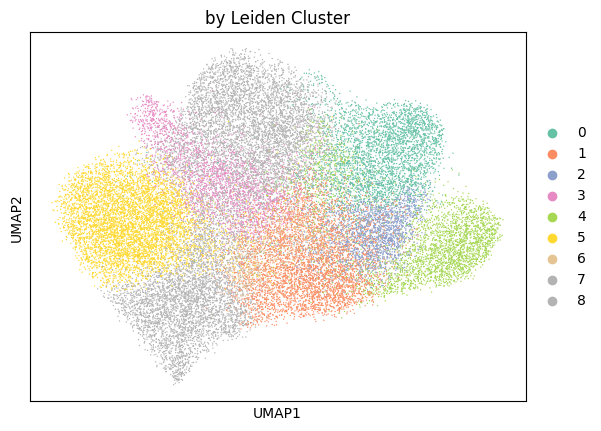

In [9]:
resolution = 1.0
leiden_key_added = f'leiden_{resolution}'
sc.tl.leiden(adata_macrophage, resolution=resolution, key_added=leiden_key_added, flavor="igraph", n_iterations=2)
sc.pl.umap(adata_macrophage, color=[leiden_key_added], ncols=2, wspace=0.4, palette='Set2', title='by Leiden Cluster')

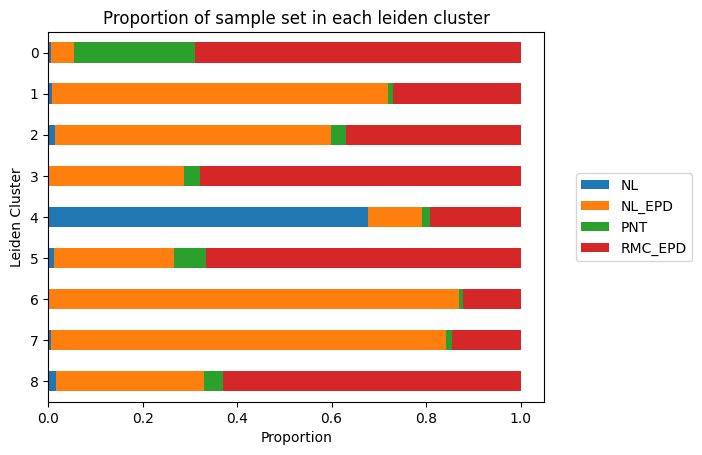

In [10]:
plot_proportions_bar(adata_macrophage, groupby=leiden_key_added, ct_col='sample_set_2', ylabel='Leiden Cluster', title='Proportion of sample set in each leiden cluster')

* PNT samples are almost entierly in leiden 0
* NL samples are almost entierly in leiden 2

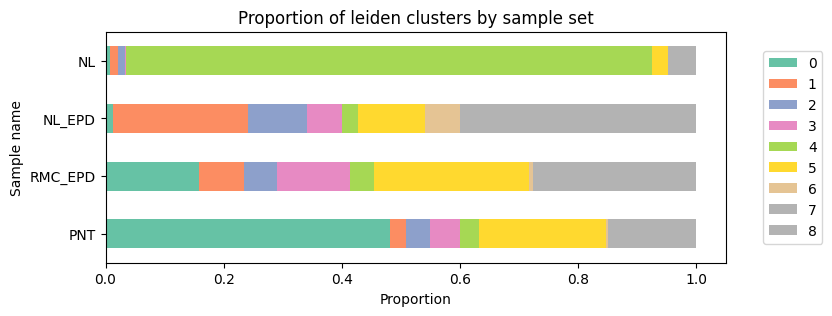

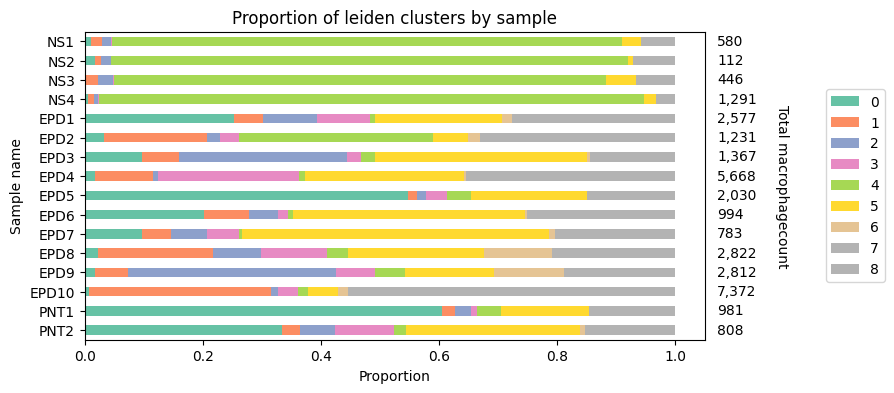

In [11]:
group_order = ['NL','NL_EPD','RMC_EPD','PNT']
sample_order = ['NS1','NS2','NS3','NS4','EPD1','EPD2','EPD3','EPD4','EPD5','EPD6','EPD7','EPD8','EPD9','EPD10','PNT1','PNT2']

plot_proportions_bar(
    adata_macrophage, groupby='sample_set_2', ct_col=leiden_key_added, 
    ylabel='Sample name', title='Proportion of leiden clusters by sample set',
    figsize=(8, 3), order=group_order
)

plot_proportions_bar(
    adata_macrophage, groupby='sample_name', ct_col=leiden_key_added, 
    ylabel='Sample name', title='Proportion of leiden clusters by sample',
    display_totals=True, display_totals_title='Total macrophagecount',
    figsize=(8, 4), order=sample_order
)

What's acually in each leiden cluster?

# Annotating  macrophage subtypes

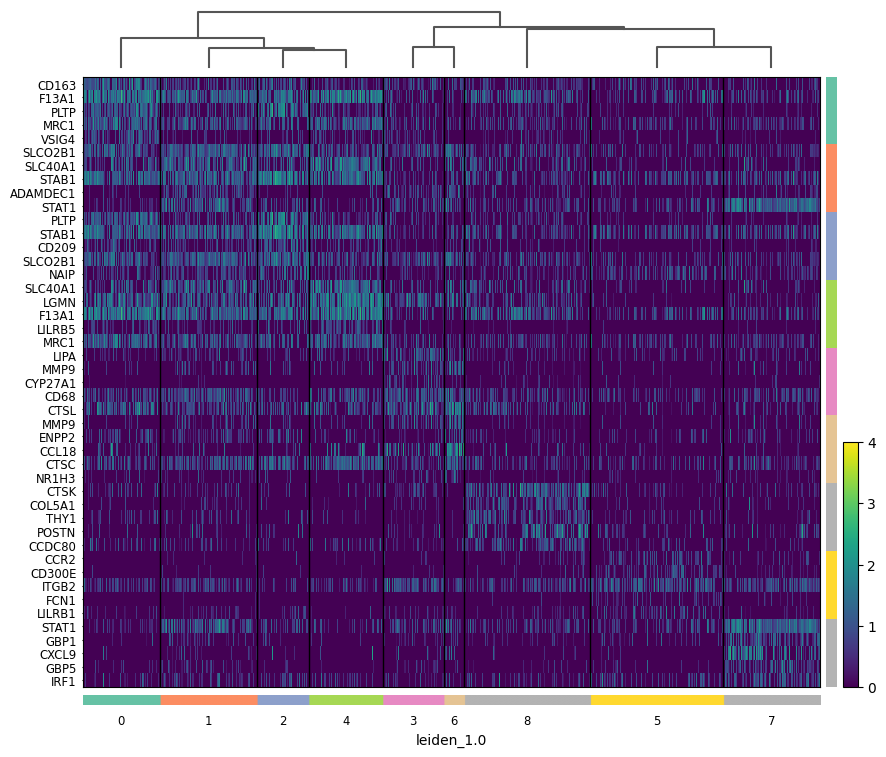

In [12]:
sc.tl.rank_genes_groups(adata_macrophage, groupby=leiden_key_added)
sc.tl.dendrogram(adata_macrophage, groupby=leiden_key_added)
sc.pl.rank_genes_groups_heatmap(adata_macrophage, groupby=leiden_key_added, show_gene_labels=True, swap_axes=True, n_genes=5)

In [13]:
genes_ranked = get_ranked_genes_by_group(adata_macrophage)


print('leiden 0: ', ', '.join(genes_ranked['0'][:10]))
print('leiden 2: ', ', '.join(genes_ranked['2'][:10]))

leiden 0:  CD163, F13A1, PLTP, MRC1, VSIG4, MARCO, CD14, SLCO2B1, LGMN, CTSL
leiden 2:  PLTP, STAB1, CD209, SLCO2B1, NAIP, DAB2, SIGLEC1, F13A1, LAIR1, CD163


Characterizing the macrophage subtypes. Pulling markers from https://www.biocompare.com/Editorial-Articles/566347-A-Guide-to-Macrophage-Markers/.

Given appropriate stimuli, macrophages are provoked and activated into a type of inflammatory state, which can be broadly grouped into either of two classes, M1 (classically activated) or M2 (alternatively activated). This nature of polarization represents opposite ends of a spectrum and refers only to an estimate of activation at a given point in time and location. M1 macrophages have been described to have a pro-inflammatory role associated with immune responses to bacteria and intracellular pathogens. On the other hand, M2 has been associated with a more anti-inflammatory role, with functions in angiogenesis and wound healing. M2 is also associated with T helper type 2 (Th2) responses, such as helminth immunity, asthma, and allergy.

M1 macrophage activation occurs through signaling by IFNG, TNF, and toll-like receptors. Genetic markers associated with M1 polarization include IL1a, IL1b, IL6, NOS2, TLR2, TLR4, CD80, and CD86. For M2 macrophages, activation occurs through cytokines including IL4, IL10, and IL13. Reported M2 markers include CD115, CD206, PPARG, ARG1, CD163, CD301, Dectin-1, PDL2, and Fizz1. It is important to note that due to the continuum of phenotypes between M1 and M2, macrophages that fall in the middle range can express some markers simultaneously.


Cancer cells are known to exploit macrophage processes in order to promote cancer progression. In the clinical setting, an increased density of macrophages in tumor sites has been correlated with poor patient survival in many types of cancer. Studies in mice have found that tumor-associated macrophages (TAMs) can stimulate tumor angiogenesis, assist with tumor cell migration and invasion, and suppress tumor immunity. These outcomes arise in part due to cancer cell signaling that influences macrophage function, as well as the production of proteins by TAMs themselves to promote tumor growth. The nature of cancer biology is complex, and similarly, TAMs can adopt distinct and diverse gene expression profiles. Some TAM markers mentioned in the literature include CCR2, CSF1R, MARCO, PDL2, CD40, CCL2, CSF1, CD16 and PDGF beta. The close relationship between macrophages in cancer continues to be an active area in research and drug development.



In [14]:
macrophage_markers = {
    'M1' : ['IL1A', 'IL1B', 'IL6', 'NOS2', 'TLR2', 'TLR4', 'CD80','CD86'],
    'M2' : ['MRC1', 'PPARG', 'ARG1', 'CD163', 'CLEC10A', 'CLEC7A', 'PDCD1LG2'], #CSF1R=CD115, MRC1=CD206, CLEC10A=CD301, CLEC7A=Dectin-1, PDCD1LG2=PDL2
    'TAM' : ['CCR2', 'MARCO', 'PDCD1LG2', 'CD40', 'CSF1', 'FCGR3A', 'PDGFB'], # PDCD1LG2=PDL2, CD16=FCGR3A
}

# feature_plots_from_marker_genes(adata_macrophage, macrophage_markers)

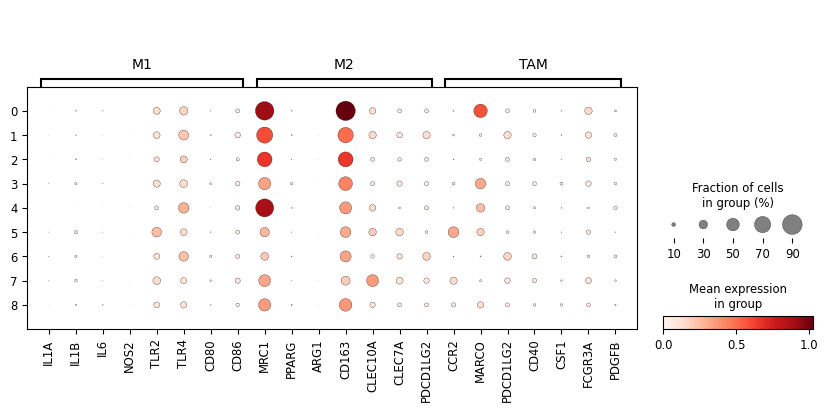

In [15]:
sc.pl.dotplot(adata_macrophage, macrophage_markers, groupby=leiden_key_added)

Having trouble annotating these...
* Leiden 0 could be TAM
* Leiden 2 could be M2

# Differential expression

Results from analysis run in `notebooks/rmc-analysis/1.20-rmc-differential-expression.ipynb`

In [24]:
diffex_results_df = pd.read_csv('output/rmc_diffex_results.csv')
diffex_results_df = diffex_results_df[diffex_results_df['ct'] == 'Macrophages']
diffex_results_df

,ct,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,sig,direction,contrast
45009,Macrophages,43.817934,-4.453580,0.389647,-11.429778,2.968676e-30,1.108801e-26,FCER2,True,down,NL vs RMC_EPD
45010,Macrophages,137.009344,2.628472,0.261145,10.065186,7.873868e-24,1.470445e-20,PLA2G7,True,up,NL vs RMC_EPD
45011,Macrophages,411.333351,-2.656663,0.286134,-9.284667,1.622142e-20,2.019567e-17,CD36,True,down,NL vs RMC_EPD
45012,Macrophages,223.865730,4.603407,0.501371,9.181637,4.245860e-20,3.964572e-17,DIO2,True,up,NL vs RMC_EPD
45013,Macrophages,427.812774,1.479152,0.162990,9.075132,1.135393e-19,8.481386e-17,MVP,True,up,NL vs RMC_EPD
...,...,...,...,...,...,...,...,...,...,...,...
330061,Macrophages,0.396206,0.944635,2.638854,0.357972,7.203646e-01,NaN,XIRP1,False,up,NL_EPD vs RMC_EPD
330062,Macrophages,0.682770,-0.428100,1.644574,-0.260311,7.946242e-01,NaN,ZAN,False,down,NL_EPD vs RMC_EPD
330063,Macrophages,0.393363,-0.184962,2.218967,-0.083355,9.335694e-01,NaN,ZDHHC22,False,down,NL_EPD vs RMC_EPD
330064,Macrophages,0.779238,-0.007698,1.288208,-0.005976,9.952322e-01,NaN,ZIC2,False,down,NL_EPD vs RMC_EPD


In [30]:
path_pattern = './output/gsea_prerank_output/Macrophages/*/gseapy.gene_set.prerank.report.csv'
gsea_result_files = [f for f in glob(path_pattern) if "all_cells" not in f and "immune_cells" not in f]

gsea_full_results = []
for path in gsea_result_files:
    df = pd.read_csv(path)
    ct = path.split('/')[-3]
    df['ct'] = ct
    comp1, comp2 = path.split('/')[-2].split('-')
    comparison = f"{comp2} vs {comp1}"
    df['comparison'] = comparison
    gsea_full_results.append(df)

gsea_full_results_df = pd.concat(gsea_full_results, ignore_index=True)
gsea_full_results_df

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,ct,comparison
0,prerank,Interferon Gamma Response,0.670811,1.797861,0.001000,0.015212,0.013,48/106,12.11%,FPR1;MVP;STAT1;PIM1;PTPN2;CDKN1A;SLAMF7;OGFR;S...,Macrophages,NL vs PNT
1,prerank,Inflammatory Response,0.657466,1.779737,0.001000,0.013457,0.023,47/138,12.11%,FPR1;PDPN;GABBR1;PLAUR;MSR1;IL1B;CDKN1A;C5AR1;...,Macrophages,NL vs PNT
2,prerank,mTORC1 Signaling,0.677744,1.762321,0.001000,0.010921,0.028,40/92,15.23%,LDHA;ITGB2;CFP;CDKN1A;SLC2A3;SDF2L1;ACLY;LTA4H...,Macrophages,NL vs PNT
3,prerank,Unfolded Protein Response,0.746293,1.733600,0.006359,0.012579,0.041,11/33,12.60%,HYOU1;EIF4A1;EIF4G1;YWHAZ;BAG3;HSPA9;EIF4A3;SH...,Macrophages,NL vs PNT
4,prerank,TNF-alpha Signaling via NF-kB,0.625948,1.671580,0.001000,0.028083,0.112,42/109,13.00%,CD44;PTX3;PLAUR;IL1B;TNC;CDKN1A;SLC2A3;MXD1;BC...,Macrophages,NL vs PNT
...,...,...,...,...,...,...,...,...,...,...,...,...
195,prerank,Mitotic Spindle,0.297081,0.798222,0.843658,0.909152,1.000,15/78,15.78%,MYH9;CTTN;ACTN4;LMNB1;STAU1;BCR;MAP1S;NCK1;TUB...,Macrophages,NL vs RMC_EPD
196,prerank,Wnt-beta Catenin Signaling,0.345731,0.795047,0.782400,0.893126,1.000,8/33,11.05%,TP53;DLL1;PPARD;NUMB;MYC;TCF7;LEF1;HDAC2,Macrophages,NL vs RMC_EPD
197,prerank,G2-M Checkpoint,0.279558,0.792778,0.893768,0.875309,1.000,33/114,23.43%,HIF1A;LMNB1;EZH2;SQLE;KPNB1;MYC;HMGA1;SMARCC1;...,Macrophages,NL vs RMC_EPD
198,prerank,Pancreas Beta Cells,0.319809,0.682183,0.891892,0.980656,1.000,3/18,14.82%,VDR;DPP4;PCSK1,Macrophages,NL vs RMC_EPD


In [26]:
path_pattern = './output/gsea_prerank_output/Macrophages/*/gseapy.gene_set.prerank.report.csv'

from glob import glob
glob(path_pattern)

# gsea_results_df = pd.read_csv('output/gsea_prerank_output/Macrophages/all_cells-RMC_EPD-vs-NL.csv')

['./output/gsea_prerank_output/Macrophages/PNT-NL/gseapy.gene_set.prerank.report.csv',
 './output/gsea_prerank_output/Macrophages/RMC_EPD-NL_EPD/gseapy.gene_set.prerank.report.csv',
 './output/gsea_prerank_output/Macrophages/NL_EPD-NL/gseapy.gene_set.prerank.report.csv',
 './output/gsea_prerank_output/Macrophages/RMC_EPD-NL/gseapy.gene_set.prerank.report.csv']

# Spatial plotting

In [16]:
adata_rmc = propogate_subset_labels(adata_rmc, adata_macrophage, 'leiden_macrophage', leiden_key_added)
adata_rmc.uns['leiden_macrophage_colors'] = adata_macrophage.uns[f'{leiden_key_added}_colors']

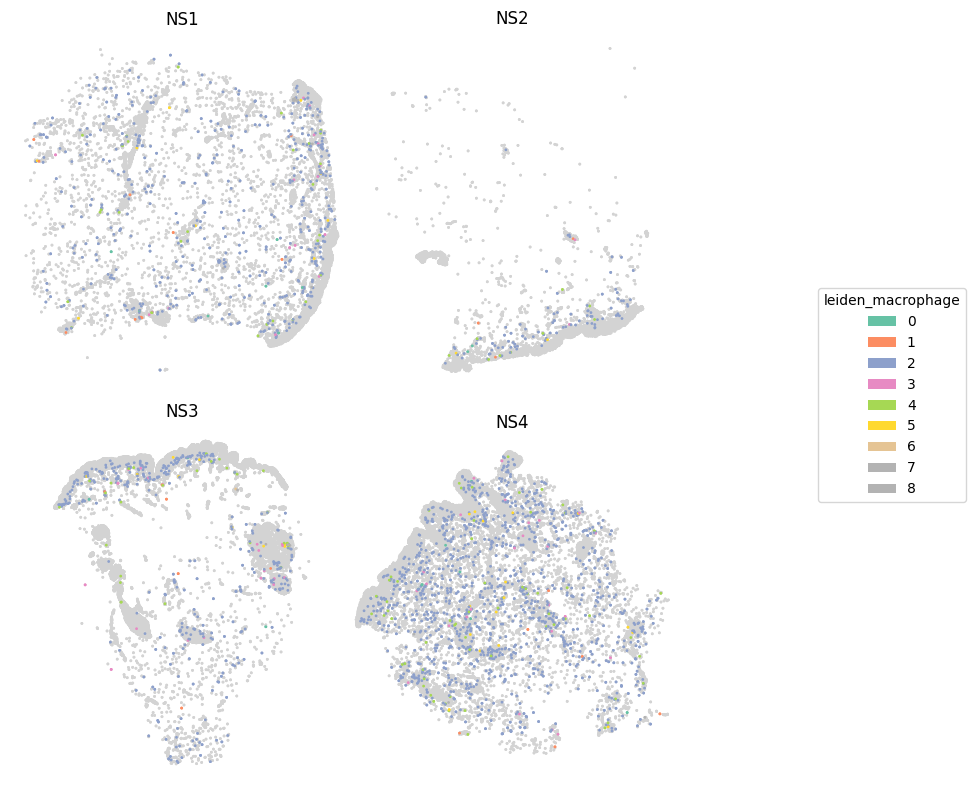

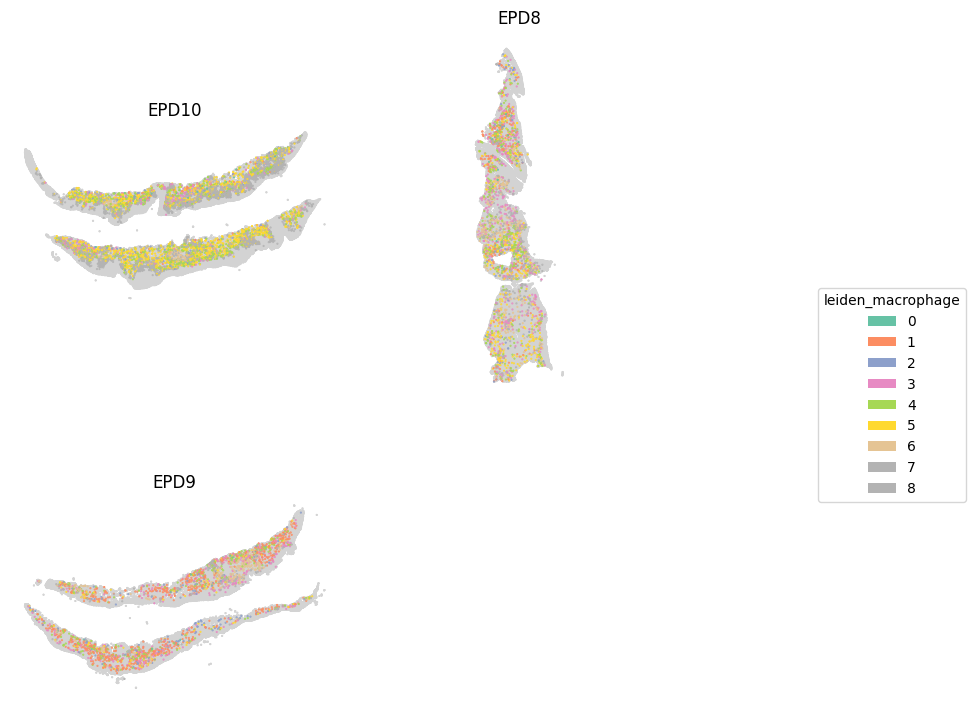

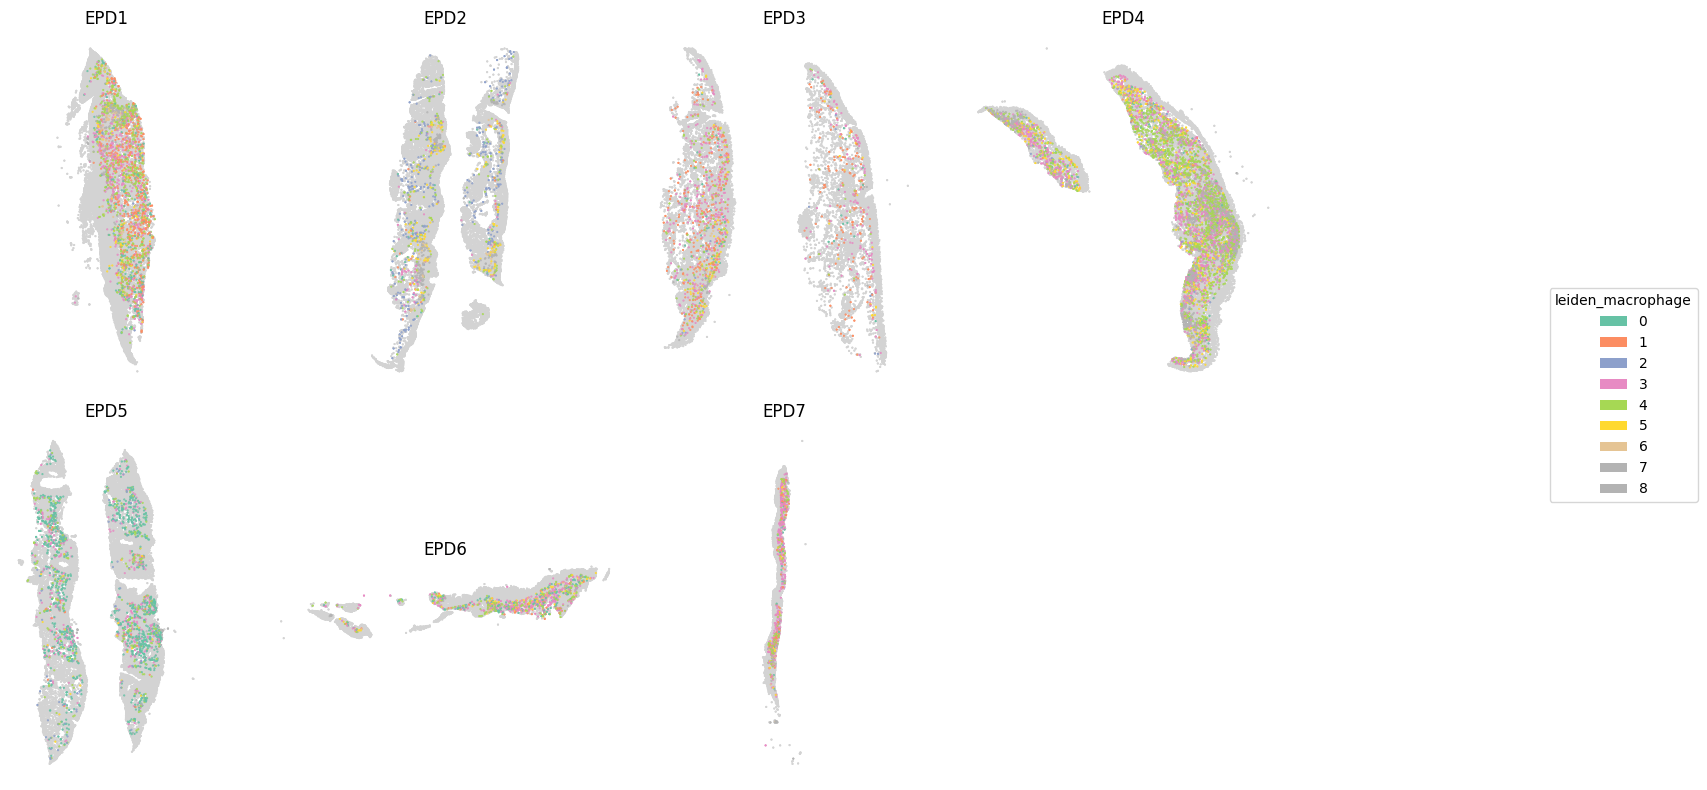

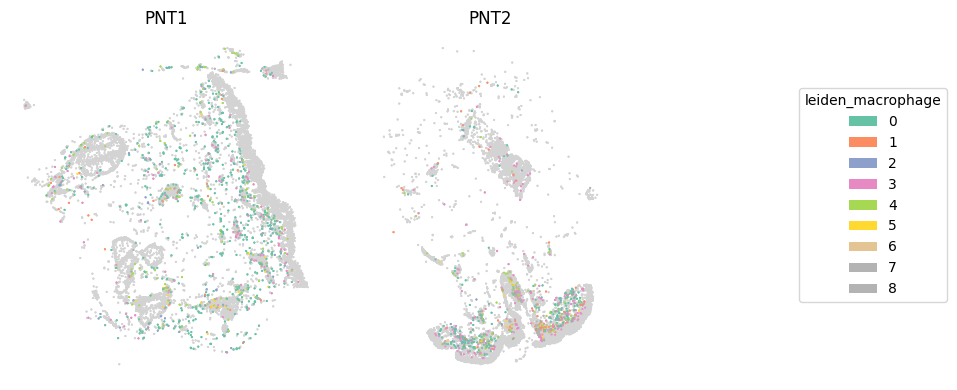

In [ ]:
spatial_plot_cell_types_layered(adata_rmc[adata_rmc.obs['sample_set_2'] == 'NL'], 'leiden_macrophage', n_cols=2, size=4)
spatial_plot_cell_types_layered(adata_rmc[adata_rmc.obs['sample_set_2'] == 'NL_EPD'], 'leiden_macrophage', n_cols=2)
spatial_plot_cell_types_layered(adata_rmc[adata_rmc.obs['sample_set_2'] == 'RMC_EPD'], 'leiden_macrophage', n_cols=4)
spatial_plot_cell_types_layered(adata_rmc[adata_rmc.obs['sample_set_2'] == 'PNT'], 'leiden_macrophage', n_cols=4)

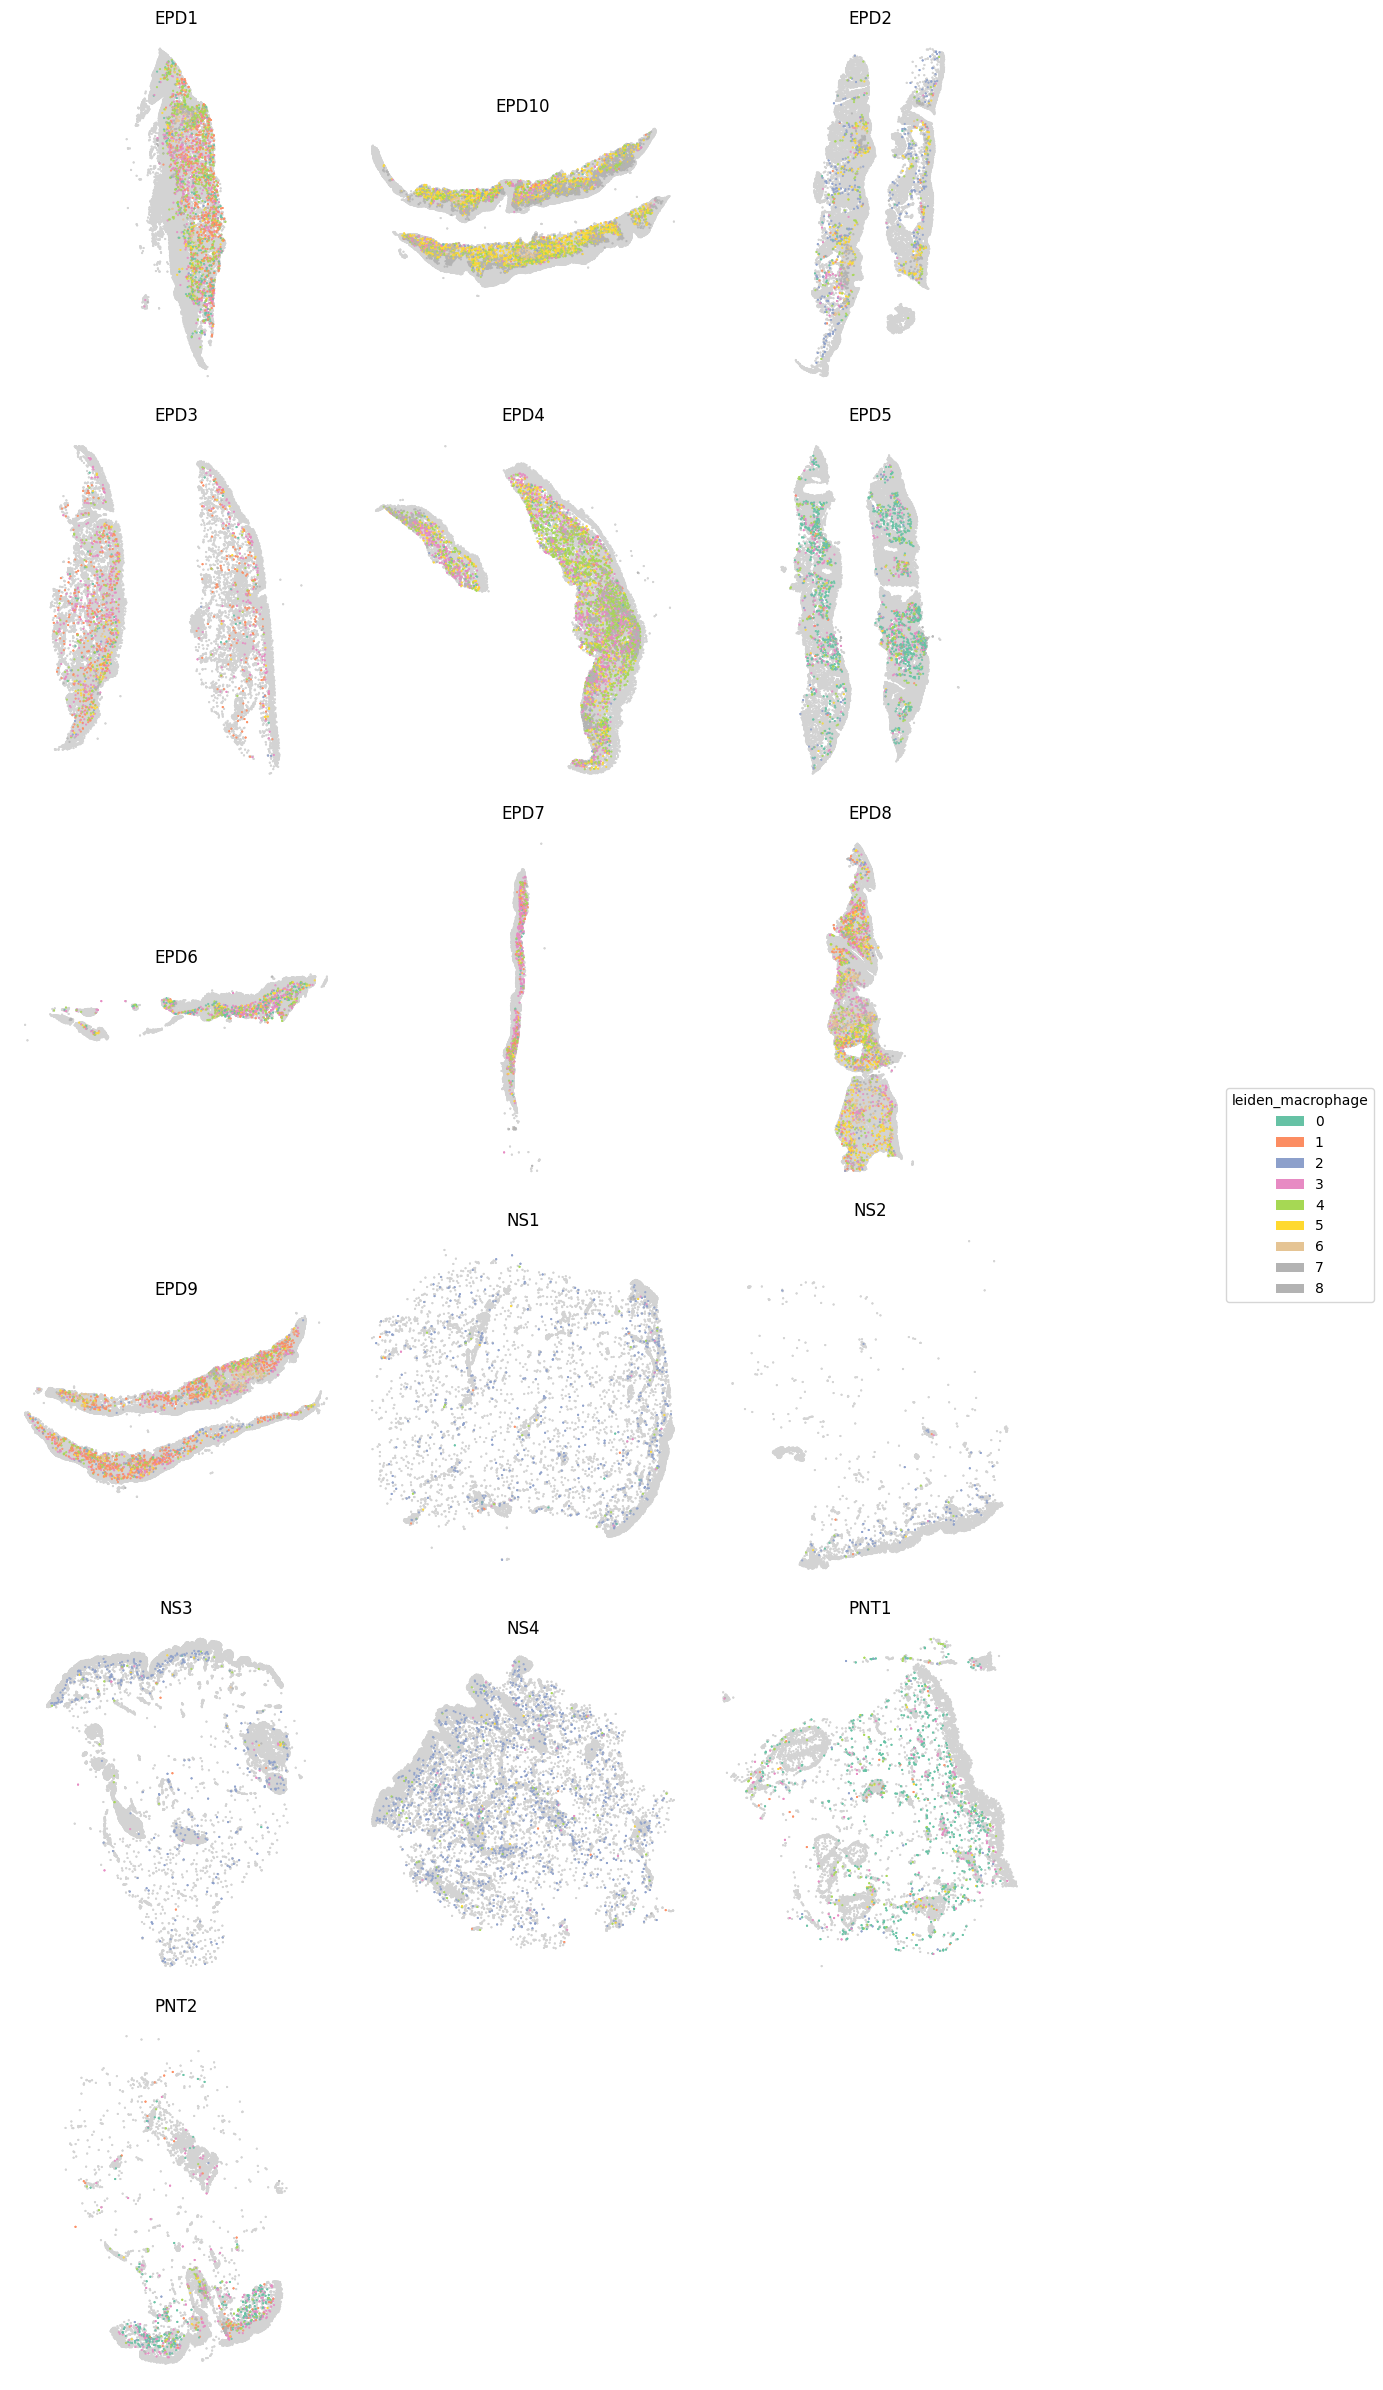

In [ ]:
spatial_plot_cell_types_layered(adata_rmc, 'leiden_macrophage')